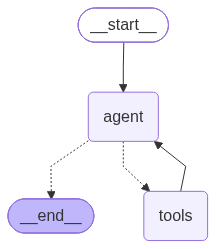

================================ Human Message =================================

试用期员工有年假吗？
================================== Ai Message ==================================

[{'data': 'gAAAAABqe_AA7J-L-knXhMgk9CtooJRu5YjzJIvJiUNRYo9DRqoK6xX2_1EgyZQAqFnsDDozl7OtVA7kyaGQwHGWPpT_iidgWtwWPU7x4sdR1gDecLL8dXpXJTMOI715DSPk5CSnZKQKOuvsVXr9xO7uw9xyHQHm36fGwrJDC-2VQ-SJLFYQkxPwC_wNaFLOUSBWhW-7b4JvdZLt5SA759PHCPAKyQGKbj2oViD0ha-dTHiIQR3_uzTki0EsCmgEKDaii4IZvPcgQrVIsQnqmAbRHh0JJnhKMU3u7N57hFMTmXfqqGcualQvDyclfPc82lCg3jqE9n2B1EVAkGhFRVdtds7Azivs6mKGJ0LYzP2-3uagIxp-V0yBcmrz2BZL_M5CUMj8hMpArRWpI4mdjZB_Mqe42eF-UXLVKw2ZijT3gZ29UHBcC12EZGKj64Mg0v_tItx7DdfV2aBSq6juvqiwM6h_AENJILr5vAjgQcCW-LpSYQsREbRHCFa7-oLiC17Vjmwi7eXxX3L-1rQK7l_4g-2qFca-swkc7TyIfyZW5e396a-OBhT1F7RpCD7AQ_vHLigK62tarBZ-HfL_hd5WCBGP_RP7EOzp6vInbepqrsr4ngZrPZw9-AP6nRDSUv4MDTyIlybWXzvdwQSS8urAnEC-ZE--naE8vK2fOOXIDz85R11ufEYjSAbHxNyIkpi26LQYoce0Zvmeo83U3C3tVnKyfgCESH93RKkPtfavQ9SgCOkQAIB6L_RYBOASOU_ncSP-rURE2r8_lDOJ-2H8vjghejiZSjt-YMQS0mW-AJ

In [2]:
import os
from langchain.tools import tool
from langchain.chat_models import init_chat_model


if "ANTHROPIC_AUTH_TOKEN" in os.environ and "ANTHROPIC_API_KEY" not in os.environ:
    os.environ["ANTHROPIC_API_KEY"] = os.environ["ANTHROPIC_AUTH_TOKEN"]

model = init_chat_model(
    "claude-sonnet-5",
    model_provider="anthropic",
    temperature=0
)


COMPANY_KNOWLEDGE = {
    "annual_leave": {
        "content": "2026年员工手册规定：正式员工每年享有10天带薪年假，试用期员工不享受带薪年假。",
        "source": "员工手册2026",
        "page": 23,
    },

    "expense": {
        "content": "单笔报销超过5000元，需要部门负责人审批。",
        "source": "财务制度2026",
        "page": 12,
    },
}



@tool
def search_company_knowledge(query: str) -> dict:
    """搜索公司制度、员工手册和内部规范。"""

    if "年假" in query or "试用期" in query:
        return COMPANY_KNOWLEDGE["annual_leave"]

    if "报销" in query:
        return COMPANY_KNOWLEDGE["expense"]

    return {
        "error": "knowledge_not_found"
    }

EMPLOYEE_DB = {
    "E1001": {
        "name": "张三",
        "status": "probation",
        "annual_leave_balance": 0,
        "department": "研发部",
    },

    "E1002": {
        "name": "李四",
        "status": "regular",
        "annual_leave_balance": 7,
        "department": "财务部",
    },
}


@tool
def query_employee(employee_id: str) -> dict:
    """查询员工当前实时信息，包括员工状态、部门和年假余额。"""

    employee = EMPLOYEE_DB.get(employee_id)

    if employee is None:
        return {
            "error": "employee_not_found"
        }

    return employee

from typing_extensions import TypedDict, Annotated
import operator

from langchain.messages import AnyMessage
from langgraph.graph.message import add_messages
class AgentState(TypedDict):
    messages: Annotated[
        list[AnyMessage],
        add_messages,
    ]


from langchain.messages import ToolMessage
tools = [
    query_employee,
    search_company_knowledge,
]

tools_by_name = {
    tool.name: tool
    for tool in tools
}

model_with_tools = model.bind_tools(tools)

from langchain.messages import SystemMessage

def agent_node(state: AgentState):

    response = model_with_tools.invoke(
        [
            SystemMessage(
                content="""
你是公司内部AI助手。

规则：

1. 查询员工当前状态、余额等实时信息时，
   必须使用 query_employee。

2. 查询公司制度、员工手册、规范时，
   必须使用 search_company_knowledge。

3. 如果一个问题同时涉及实时员工信息和公司制度，
   可以连续调用多个工具。

4. 不允许编造公司内部信息。

5. 如果知识库没有找到资料，
   明确告诉用户无法确认。
"""
            )
        ]
        + state["messages"]
    )

    return {
        "messages": [response]
    }









def tool_node(state: AgentState):
    last_message = state["messages"][-1]

    results = []

    for tool_call in last_message.tool_calls:
        tool = tools_by_name[
            tool_call["name"]
        ]

        observation = tool.invoke(
            tool_call["args"]
        )

        results.append(
            ToolMessage(
                content=str(observation),
                tool_call_id=tool_call["id"],
            )
        )

    return {
        "messages": results
    }

    



# Step 5: Define logic to determine whether to end
from typing import Literal
from langgraph.graph import END


def route_after_agent(
    state: AgentState,
) -> Literal["tools", "__end__"]:

    last_message = state["messages"][-1]

    if last_message.tool_calls:
        return "tools"

    return END
    



# Step 6: Build agent
from langgraph.graph import (
    START,
    StateGraph,
)


builder = StateGraph(AgentState)

builder.add_node(
    "agent",
    agent_node,
)

builder.add_node(
    "tools",
    tool_node,
)

builder.add_edge(
    START,
    "agent",
)

builder.add_conditional_edges(
    "agent",
    route_after_agent,
    {
        "tools": "tools",
        "__end__": END,
    },
)

builder.add_edge(
    "tools",
    "agent",
)

graph = builder.compile()


from langchain.messages import HumanMessage


from IPython.display import Image, display
# Show the agent
display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

# Invoke
resultDepartment = graph.invoke({
    "messages": [
        HumanMessage(
            content=(
                "试用期员工有年假吗？"
            )
        )
    ]
})

for message in resultDepartment["messages"]:
    message.pretty_print()
    

resultWeather = graph.invoke({
    "messages": [
        HumanMessage(
            content=(
                "E1002 现在还有多少年假？"
            )
        )
    ]
})


for message in resultWeather["messages"]:
    message.pretty_print()


result = graph.invoke({
    "messages": [
        HumanMessage(
            content=(
                "E1001 为什么没有年假？"
            )
        )
    ]
})

for message in result["messages"]:
    message.pretty_print()

    